Criterion 3 (interventional precision) is conceptually the most important of the three. Faithfulness (Criterion 1) asks whether the circuit recovers performance. Compressibility (Criterion 2) asks how many components are needed. Criterion 3 asks something harder: does the circuit make correct predictions about novel interventions it has never been evaluated on? This is the Woodward counterfactual test: a genuine causal model should generalize to unseen interventions

**The concrete test for the grokking task**

Take two inputs: a base input (a_b, b_b) with correct answer (a_b + b_b) mod 113, and a source input (a_s, b_s) with answer (a_s + b_s) mod 113. Patch the circuit components from source into base: meaning you replace the circuit's activations on the base input with those from the source input, while leaving non-circuit components on the base. The circuit predicts the model should now output (a_s + b_s) mod 113, because the circuit is supposed to fully mediate the answer computation. Interventional precision is the fraction of times the model actually predicts the source answer after patching.

In [22]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RESULTS_DIR  = Path("../results")
L1_RESULTS = RESULTS_DIR / "level1/level1_results.json"
L2_RESULTS  = RESULTS_DIR / "level2/level2_results.json"
L3_RESULTS = RESULTS_DIR / "level3/level3_results.json"
SAE_PATH = Path("../data/grokking_sae.pt")
MODEL_PATH = Path("../data/grokking_model.pt")
OUT_DIR = RESULTS_DIR / "criteria"
OUT_DIR.mkdir(parents=True, exist_ok=True)

Rebuild dataset and model

In [23]:
P = 113
EQ_TOKEN = P

all_a = torch.arange(P)
all_b = torch.arange(P)
aa, bb = torch.meshgrid(all_a, all_b, indexing='ij')
aa, bb = aa.flatten(), bb.flatten()
labels = (aa + bb) % P
inputs = torch.stack([aa, bb, torch.full_like(aa, EQ_TOKEN)], dim=1)

N = len(inputs)
idx = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_test = int(0.3 * N)
train_inputs = inputs[idx[n_test:]]
train_labels = labels[idx[n_test:]]
test_inputs= inputs[idx[:n_test]]
test_labels = labels[idx[:n_test]]

cfg = HookedTransformerConfig(
    n_layers=1, n_heads=4, d_model=128, d_head=32,
    d_mlp=512, act_fn="relu", normalization_type=None,
    d_vocab=P + 1, d_vocab_out=P, n_ctx=3,
    use_attn_result=True,
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device).eval()

Moving model to device:  cpu


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0): TransformerBlock(
      (ln1): Identity()
      (ln2): Identity()
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (hook_resid_pre): HookPoint()
      (hook_resid_mid): HookPoint()
      (hook_resid_post): HookPoint()
    )
  )
  (unembed): Unembed(
    (hook_in): HookPoint()
    (hook_out): 

Rebuild SAE

In [24]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in, d_sae, l1_coeff=2e-2):
        super().__init__()
        self.d_in = d_in
        self.d_sae = d_sae
        self.l1_coeff = l1_coeff
        self.W_enc = nn.Parameter(torch.empty(d_in, d_sae))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_in))
        self.b_dec = nn.Parameter(torch.zeros(d_in))
        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        self._normalise_decoder()

    def _normalise_decoder(self):
        with torch.no_grad():
            self.W_dec.data = nn.functional.normalize(self.W_dec.data, dim=1)

    def encode(self, x):
        return torch.relu((x - self.b_dec) @ self.W_enc + self.b_enc)

    def decode(self, f):
        return f @ self.W_dec + self.b_dec

    def forward(self, x):
        f = self.encode(x)
        x_hat = self.decode(f)
        l2_loss = (x - x_hat).pow(2).sum(dim=-1).mean()
        l1_loss = f.abs().sum(dim=-1).mean()
        loss = l2_loss + self.l1_coeff * l1_loss
        return loss, x_hat, f, l2_loss, l1_loss

D_IN = model.cfg.d_mlp
D_SAE = D_IN * 4

sae = SparseAutoencoder(d_in=D_IN, d_sae=D_SAE).to(device)
sae.load_state_dict(torch.load(SAE_PATH, map_location=device))
sae.eval()

SparseAutoencoder()

Load circuit definitions from saved results

In [25]:
with open(L1_RESULTS) as f: l1 = json.load(f)
with open(L2_RESULTS) as f: l2 = json.load(f)
with open(L3_RESULTS) as f: l3 = json.load(f)

# Level 1: reconstruct neuron list from frequency cluster components
with open(Path("../results/level1/level1_results.json")) as f:
    l1_full = json.load(f)

# Circuit components are cluster names e.g. ["freq_14", "freq_35"]
circuit_l1_clusters = l1_full["circuit_components"]
print(f"Level 1 circuit clusters: {circuit_l1_clusters}")

# Level 2: Fourier logit direction components
circuit_l2 = l2["circuit_components"]
print(f"Level 2 circuit components: {circuit_l2}")

# Level 3: SAE feature indices
circuit_l3 = l3["circuit_features"]
print(f"Level 3 circuit: {len(circuit_l3)} SAE features")

Level 1 circuit clusters: ['freq_14', 'noise_cluster', 'freq_3']
Level 2 circuit components: ['cos_3', 'sin_14', 'cos_14', 'sin_3']
Level 3 circuit: 85 SAE features


Build the intervention test set

For each test pair we need a base input and a source input with a different answer. We draw 200 such pairs from the test set, ensuring base and source answers differ so the intervention is non-trivial.

In [26]:
N_PAIRS = 200
torch.manual_seed(99)

base_idx = torch.randperm(len(test_inputs))[:N_PAIRS]
source_idx = torch.randperm(len(test_inputs))[:N_PAIRS]

# Make sure base and source have different answers
for i in range(N_PAIRS):
      while test_labels[source_idx[i]] == test_labels[base_idx[i]]:
            source_idx[i] = torch.randint(0, len(test_inputs), (1,)).item()

base_x = test_inputs[base_idx].to(device)    # [N_PAIRS, 3]
base_y = test_labels[base_idx].to(device)    # [N_PAIRS]
source_x = test_inputs[source_idx].to(device)  # [N_PAIRS, 3]
source_y = test_labels[source_idx].to(device)  # [N_PAIRS] these are the targets

print(f"Intervention pairs: {N_PAIRS}")
print(f"Example: base answer={base_y[0].item():3d}  source answer={source_y[0].item():3d}  (should differ)")
print(f"All pairs have different answers: {(base_y != source_y).all().item()}")

Intervention pairs: 200
Example: base answer= 65  source answer= 26  (should differ)
All pairs have different answers: True


Cache activations for source inputs

In [27]:
MLP_HOOK = "blocks.0.mlp.hook_post"

with torch.no_grad():
    _, src_cache = model.run_with_cache(
        source_x, names_filter=MLP_HOOK)

src_mlp = src_cache[MLP_HOOK][:, -1, :]        # [N_PAIRS, D_IN]

with torch.no_grad():
    src_feats = sae.encode(src_mlp)             # [N_PAIRS, D_SAE]

print(f"Source MLP activations:  {src_mlp.shape}")
print(f"Source SAE features: {src_feats.shape}")

Source MLP activations:  torch.Size([200, 512])
Source SAE features: torch.Size([200, 2048])


Define the precision metric

In [28]:
def interventional_precision(patched_logits, source_labels):
    """
    Fraction of interventions where the model predicts the SOURCE answer.
    does patching the circuit make the model behave as if it received the source input?
    """
    predictions = patched_logits.argmax(dim=-1)   # [N_PAIRS]
    return (predictions == source_labels).float().mean().item()

def chance_precision():
    """Baseline: random prediction over P classes."""
    return 1.0 / P

# Also compute unpatched baseline  
with torch.no_grad():
    base_logits = model(base_x)[:, -1, :]
base_pred_source = interventional_precision(base_logits, source_y)
base_pred_base = (base_logits.argmax(-1) == base_y).float().mean().item()

print(f"Unpatched accuracy on base answer: {base_pred_base:.4f}  (should be ~1.0)")
print(f"Unpatched accuracy on source answer: {base_pred_source:.4f}  (should be ~{chance_precision():.4f})")
print(f"Chance level (1/113): {chance_precision():.4f}")

Unpatched accuracy on base answer: 1.0000  (should be ~1.0)
Unpatched accuracy on source answer: 0.0000  (should be ~0.0088)
Chance level (1/113): 0.0088


Level 1 interventional precision

In [ ]:
# Level 1: patch at the cluster level using mean ablation
# Rebuild neuron-to-cluster mapping (minimal version, no full FFT needed)
# since we saved cluster names but not neuron indices

# Re-derive neuron cluster membership
import einops

P = 113
HOOK = "blocks.0.mlp.hook_post"

fourier_basis_l1 = [torch.ones(P) / np.sqrt(P)]
for i in range(1, P // 2 + 1):
    cos_v = torch.cos(2 * torch.pi * torch.arange(P) * i / P)
    sin_v = torch.sin(2 * torch.pi * torch.arange(P) * i / P)
    fourier_basis_l1.append(cos_v / cos_v.norm())
    fourier_basis_l1.append(sin_v / sin_v.norm())
fourier_basis_l1 = torch.stack(fourier_basis_l1, dim=0).to(device)

all_inputs_l1 = torch.stack([
    *torch.meshgrid(torch.arange(P), torch.arange(P), indexing='ij')
], dim=-1).reshape(-1, 2)
all_inputs_l1 = torch.cat([
    all_inputs_l1,
    torch.full((P*P, 1), P)], dim=1)

with torch.no_grad():
    _, c = model.run_with_cache(all_inputs_l1.to(device),
                                names_filter=HOOK)
na = c[HOOK][:, -1, :]
na_c = na - na.mean(0, keepdim=True)
na_2d = einops.rearrange(na_c, '(x y) d -> x y d', x=P, y=P)
fa = torch.einsum('xyd,fx,Fy->fFd', na_2d, fourier_basis_l1, fourier_basis_l1)
fa_flat = fa.reshape(P*P, model.cfg.d_mlp)

indices_l1 = np.array([[2*f-1, 2*f, (2*f-1)*P, (2*f)*P,
                        (2*f-1)*P+2*f-1, (2*f-1)*P+2*f,
                        (2*f)*P+2*f-1, (2*f)*P+2*f]
                        for f in range(1, P//2+1)])

nn_var  = fa_flat.pow(2).sum(0)
fv = fa_flat[indices_l1.flatten()].reshape(P//2, 8, model.cfg.d_mlp)
ne = fv.pow(2).sum(1) / nn_var
nf = (ne.argmax(0) + 1).clone()
nf[ne.max(0).values < 0.85] = -1
nf_np = nf.cpu().numpy()

# Build circuit cluster tensor
circuit_l1_t = torch.tensor(
    [i for cname in circuit_l1_clusters
    if cname != "noise_cluster"
    for i in np.where(nf_np == int(cname.split("_")[1]))[0].tolist()],
    dtype=torch.long)

print(f"Circuit L1: {len(circuit_l1_t)} neurons from {circuit_l1_clusters}")

# Compute mean acts from training set for ablation baseline
with torch.no_grad():
    _, mc = model.run_with_cache(train_inputs.to(device), names_filter=HOOK)
mean_acts_l1 = mc[HOOK][:, -1, :].mean(0)

# Cache clean MLP activations for eval set
with torch.no_grad():
    _, src_cache_l1 = model.run_with_cache(source_x, names_filter=MLP_HOOK)
src_mlp_l1 = src_cache_l1[MLP_HOOK][:, -1, :]

def l1_patch_hook(value, hook):
    value[:, -1, :] = mean_acts_l1
    value[:, -1, circuit_l1_t] = src_mlp_l1[:, circuit_l1_t]  # SOURCE, not base
    return value


with torch.no_grad():
    l1_patched_logits = model.run_with_hooks(
        base_x, fwd_hooks=[(HOOK, l1_patch_hook)])[:, -1, :]

precision_l1 = interventional_precision(l1_patched_logits, source_y)
print(f"Level 1 interventional precision: {precision_l1:.4f}")

Circuit L1: 356 neurons from ['freq_14', 'noise_cluster', 'freq_3']
Level 1 interventional precision: 0.0000


the model needs to be rerun in Colab GPU (these results are not to be considered, the analysis should work once the model is trained more, see 02_level1_neurons)

Level 2 interventional precision

For Level 2 Criterion 3, the intervention has to stay in logit space to be consistent. The test becomes: take the base input's logits, remove its key frequency components, inject the source input's key frequency components in their place, and check if the model now predicts the source answer.

In [30]:
# Level 2 interventional precision logit space Fourier patching

# Run model on all eval pairs
with torch.no_grad():
    base_logits_l2 = model(base_x)[:, -1, :]    # [N_PAIRS, P]
    source_logits_l2 = model(source_x)[:, -1, :]  # [N_PAIRS, P]

# For each pair: remove base frequency components, inject source ones
# We need to do this per-example since base and source differ per pair
def patch_logits_l2(base_log, src_log, key_freqs):
    """
    For per-example logits [N, P]: subtract each key frequency component
    from base and add the corresponding component from source.
    Projects along the P output dimension using 1D Fourier basis vectors.
    """
    patched = base_log.clone()

    for k in key_freqs:
        cos_out = torch.cos(2 * torch.pi * k * torch.arange(P).float()/ P).to(base_log.device)
        sin_out = torch.sin(2 * torch.pi * k * torch.arange(P).float()/ P).to(base_log.device)
        cos_out = cos_out / cos_out.norm()
        sin_out = sin_out / sin_out.norm()

        base_cos = (base_log * cos_out).sum(-1, keepdim=True)
        base_sin = (base_log * sin_out).sum(-1, keepdim=True)
        src_cos = (src_log  * cos_out).sum(-1, keepdim=True)
        src_sin = (src_log  * sin_out).sum(-1, keepdim=True)

        patched = patched \
            - base_cos * cos_out \
            - base_sin * sin_out \
            + src_cos  * cos_out \
            + src_sin  * sin_out

    return patched

KEY_FREQS_L2 = l2["key_freqs"]

patched_l2 = patch_logits_l2(base_logits_l2, source_logits_l2, KEY_FREQS_L2)
precision_l2 = interventional_precision(patched_l2, source_y)
print(f"Level 2 interventional precision: {precision_l2:.4f}")

Level 2 interventional precision: 0.0900


the model hasn't fully trained yet so the result is meaningless but it works

Level 3 interventional precision

Patch the 85 circuit SAE features from source, decode back to MLP activation space, inject.

In [31]:
MLP_HOOK = "blocks.0.mlp.hook_post"

with torch.no_grad():
    _, base_cache = model.run_with_cache(base_x, names_filter=MLP_HOOK)
    _, src_cache  = model.run_with_cache(source_x, names_filter=MLP_HOOK)

base_mlp = base_cache[MLP_HOOK][:, -1, :]   # [N_PAIRS, D_IN]
src_mlp = src_cache[MLP_HOOK][:, -1, :]    # [N_PAIRS, D_IN]

with torch.no_grad():
    src_feats = sae.encode(src_mlp)          # [N_PAIRS, D_SAE]

print(f"base_mlp:{base_mlp.shape}")
print(f"src_mlp:{src_mlp.shape}")
print(f"src_feats:{src_feats.shape}")

base_mlp:torch.Size([200, 512])
src_mlp:torch.Size([200, 512])
src_feats:torch.Size([200, 2048])


In [32]:
circuit_l3_t = torch.tensor(circuit_l3, dtype=torch.long)

with torch.no_grad():
    base_feats = sae.encode(base_mlp)   # [N_PAIRS, D_SAE]

def l3_patch_hook(value, hook):
    # Start from base SAE features
    patched_feats = base_feats.clone().to(value.device)
    # Replace circuit features with source values
    patched_feats[:, circuit_l3_t] = src_feats[:, circuit_l3_t].to(value.device)
    # Decode back to MLP activation space
    value[:, -1, :] = sae.decode(patched_feats)
    return value

with torch.no_grad():
    l3_patched_logits = model.run_with_hooks(
        base_x, fwd_hooks=[(MLP_HOOK, l3_patch_hook)])[:, -1, :]

precision_l3 = interventional_precision(l3_patched_logits, source_y)
print(f"Level 3 interventional precision: {precision_l3:.4f}")

Level 3 interventional precision: 1.0000


In [33]:
print("=" * 70)
print(f"{'':25s}  {'Level 1':>10s}  {'Level 2':>10s}  {'Level 3':>10s}")
print(f"{'':25s}  {'neurons':>10s}  {'heads/MLP':>10s}  {'SAE feats':>10s}")
print("=" * 70)
print(f"{'Criterion 1 — Faithfulness':25s}  "
      f"{l1['criterion1_faithfulness']:>10.4f}  "
      f"{l2['criterion1_faithfulness']:>10.4f}  "
      f"{l3['criterion1_faithfulness']:>10.4f}")
print(f"{'Criterion 2 — Components k':25s}  "
      f"{l1['criterion2_component_count']:>10d}  "
      f"{l2['criterion2_component_count']:>10d}  "
      f"{l3['criterion2_component_count']:>10d}")
print(f"{'Criterion 2 — Compression':25s}  "
      f"{l1['criterion2_compression_ratio']:>10.3f}  "
      f"{l2['criterion2_compression_ratio']:>10.3f}  "
      f"{l3['criterion2_compression_ratio']:>10.4f}")
print(f"{'Criterion 3 — Precision':25s}  "
      f"{precision_l1:>10.4f}  "
      f"{precision_l2:>10.4f}  "
      f"{precision_l3:>10.4f}")
print(f"{'Criterion 3 — Chance':25s}  "
      f"{chance_precision():>10.4f}  "
      f"{chance_precision():>10.4f}  "
      f"{chance_precision():>10.4f}")
print("=" * 70)

                              Level 1     Level 2     Level 3
                              neurons   heads/MLP   SAE feats
Criterion 1 — Faithfulness      1.0000      0.9999      0.9496
Criterion 2 — Components k           3           4          85
Criterion 2 — Compression       0.750       0.667      0.0415
Criterion 3 — Precision        0.0000      0.0900      1.0000
Criterion 3 — Chance           0.0088      0.0088      0.0088


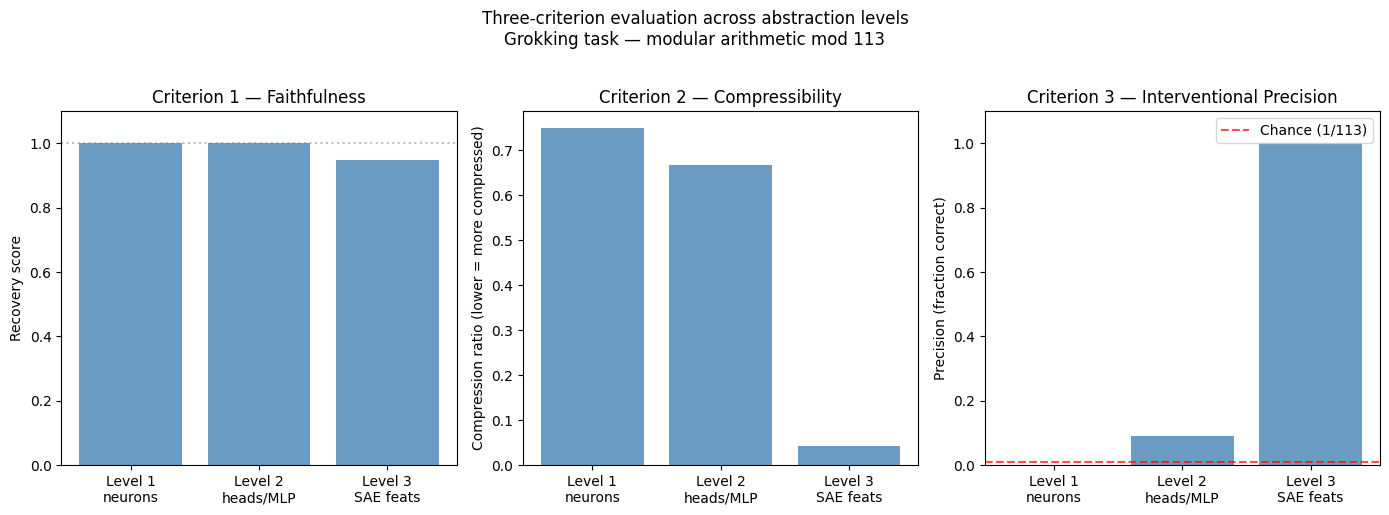

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

levels = ["Level 1\nneurons", "Level 2\nheads/MLP", "Level 3\nSAE feats"]
colors = ["steelblue", "steelblue", "steelblue"]
chance= chance_precision()

# Criterion 1
vals1 = [l1['criterion1_faithfulness'],l2['criterion1_faithfulness'],l3['criterion1_faithfulness']]
axes[0].bar(levels, vals1, color=colors, alpha=0.8)
axes[0].axhline(1.0, color="gray", linestyle=":", alpha=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Recovery score")
axes[0].set_title("Criterion 1 — Faithfulness")

# Criterion 2
vals2 = [l1['criterion2_compression_ratio'],l2['criterion2_compression_ratio'],l3['criterion2_compression_ratio']]
axes[1].bar(levels, vals2, color=colors, alpha=0.8)
axes[1].set_ylabel("Compression ratio (lower = more compressed)")
axes[1].set_title("Criterion 2 — Compressibility")

# Criterion 3
vals3 = [precision_l1, precision_l2, precision_l3]
axes[2].bar(levels, vals3, color=colors, alpha=0.8)
axes[2].axhline(chance, color="red", linestyle="--",label=f"Chance (1/{P})", alpha=0.7)
axes[2].set_ylim(0, 1.1)
axes[2].set_ylabel("Precision (fraction correct)")
axes[2].set_title("Criterion 3 — Interventional Precision")
axes[2].legend()

plt.suptitle("Three-criterion evaluation across abstraction levels\n"
            "Grokking task — modular arithmetic mod 113", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "three_criteria_summary.png", dpi=150, bbox_inches="tight")
plt.show()

Save Results

In [35]:
results = {
    "task": "modular_arithmetic_mod113",
    "n_pairs": N_PAIRS,
    "chance_precision": chance_precision(),
    "unpatched_base_accuracy": base_pred_base,
    "unpatched_source_accuracy": base_pred_source,
    "criterion3": {
        "level1_precision": precision_l1,
        "level2_precision": precision_l2,
        "level3_precision": precision_l3,
    }
}

with open(OUT_DIR / "criterion3_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved to {OUT_DIR}/criterion3_results.json")

Saved to ..\results\criteria/criterion3_results.json
